In [1]:
# ===============================================================================
#    This sample illustrates how to grab and process images using the CInstantCamera class.
#    The images are grabbed and processed asynchronously, i.e.,
#    while the application is processing a buffer, the acquisition of the next buffer is done
#    in parallel.
#
#    The CInstantCamera class uses a pool of buffers to retrieve image data
#    from the camera device. Once a buffer is filled and ready,
#    the buffer can be retrieved from the camera object for processing. The buffer
#    and additional image data are collected in a grab result. The grab result is
#    held by a smart pointer after retrieval. The buffer is automatically reused
#    when explicitly released or when the smart pointer object is destroyed.
# ===============================================================================
from pypylon import pylon
from pypylon import genicam

import sys

In [2]:
import matplotlib.pyplot as plt

In [3]:
1/30 * 1e6

33333.333333333336

In [4]:
# Number of images to be grabbed.
countOfImagesToGrab = 5

In [5]:
# The exit code of the sample application.
exitCode = 0

In [6]:
# Create an instant camera object with the camera device found first.
tl_factory = pylon.TlFactory.GetInstance()

In [7]:
devices_info = [ ]
for i, device in enumerate( tl_factory.EnumerateDevices() ):
    devices_info.append( device )
    print( f"({i})", device.GetFullName() )

(0) Basler acA720-290gm#00305336CB66#169.254.1.2:3956


In [8]:
devices_info

[<pypylon.pylon.DeviceInfo; proxy of <Swig Object of type 'Pylon::CDeviceInfo *' at 0x000001F407988570> >]

In [9]:
device_info = devices_info[0]

In [10]:
str(device)

"<pypylon.pylon.DeviceInfo; proxy of <Swig Object of type 'Pylon::CDeviceInfo *' at 0x000001F407988570> >"

In [13]:
device.GetFriendlyName()

'Basler acA720-290gm (40191337)'

In [11]:
device.GetFullName()

'Basler acA720-290gm#00305336CB66#169.254.1.2:3956'

In [9]:
camera = pylon.InstantCamera( tl_factory.CreateDevice( devices_info[0] ) )

In [10]:
camera.Open()

In [11]:
for n in dir(camera):
    if "auto" in n.lower():
        print(n) 

AutoExposureTimeAbsLowerLimit
AutoExposureTimeAbsUpperLimit
AutoExposureTimeLowerLimitRaw
AutoExposureTimeUpperLimitRaw
AutoFunctionAOIHeight
AutoFunctionAOIOffsetX
AutoFunctionAOIOffsetY
AutoFunctionAOISelector
AutoFunctionAOIUsageIntensity
AutoFunctionAOIUsageWhiteBalance
AutoFunctionAOIWidth
AutoFunctionAOIs
AutoFunctionProfile
AutoFunctions
AutoGainRawLowerLimit
AutoGainRawUpperLimit
AutoTargetValue
BalanceWhiteAuto
ExposureAuto
GainAuto


In [12]:
# Print the model name of the camera.
print("Using device ", camera.GetDeviceInfo().GetModelName())

Using device  acA720-290gm


In [13]:
# demonstrate some feature access
new_width = camera.Width.Value - camera.Width.Inc
if new_width >= camera.Width.Min:
    camera.Width.Value = new_width

camera.Width.Value, camera.Width.Inc

(719, 1)

In [14]:
camera.Width.Value = 720
camera.Width.Value

720

In [15]:
# https://docs.baslerweb.com/pylonapi/cpp/class_pylon_1_1_c_instant_camera
# this is the C++ API
# pypylon api is not known
type(camera)

pypylon.pylon.InstantCamera

In [16]:
# https://docs.baslerweb.com/exposure-mode
camera.ExposureMode.Value

'Timed'

In [17]:
# https://docs.baslerweb.com/exposure-time
camera.ExposureTimeAbs.Value

15000.0

In [18]:
camera.ExposureTimeMode.Value

'Standard'

In [19]:
camera.ExposureAuto.Value

'Off'

In [20]:
# The parameter MaxNumBuffer can be used to control the count of buffers
# allocated for grabbing. The default value of this parameter is 10.
# camera.MaxNumBuffer.Value = 15
camera.MaxNumBuffer.Value

10

In [21]:
camera.GainRaw.Value

200

In [22]:
camera.GainSelector.Value

'All'

In [23]:
camera.GainAuto.Value

'Off'

In [24]:
# this does not matter if the AutoExposure is off
camera.AutoTargetValue.Value

2048

In [25]:
camera.AcquisitionFrameRateEnable.Value

False

In [26]:
camera.AcquisitionFrameRateAbs.Value

100.0

In [27]:
camera.Gamma.Value

1.0

In [28]:
camera.GammaEnable.Value

True

In [29]:
camera.BlackLevelRaw.Value

0

In [30]:
camera.BlackLevelSelector.Value

'All'

In [31]:
# this is not accessable
# camera.BalanceWhiteAuto.Value

In [32]:
# this is not accessable
# camera.LightSourceSelector.Value

In [33]:
# this is not accessable
# camera.BslBrightness.Value

In [34]:
camera.AutoFunctionProfile.Value

'GainMinimum'

In [35]:
for aoi in camera.AutoFunctionAOISelector.GetSymbolics():
    print(aoi)
    camera.AutoFunctionAOISelector.SetValue(aoi)
    print(camera.AutoFunctionAOIUsageIntensity.Value)
    print(camera.AutoFunctionAOIUsageWhiteBalance.Value)

AOI1
False
False
AOI2
False
False


In [37]:
# https://docs.baslerweb.com/pixel-format
camera.PixelFormat.Value

# avaliable format for acA720-290gm 	
# Mono 8
# Mono 12
# Mono 12 Packed

'Mono12'

SizeX:  720 SizeY:  540
SizeX:  720 SizeY:  540
SizeX:  720 SizeY:  540
SizeX:  720 SizeY:  540
SizeX:  720 SizeY:  540


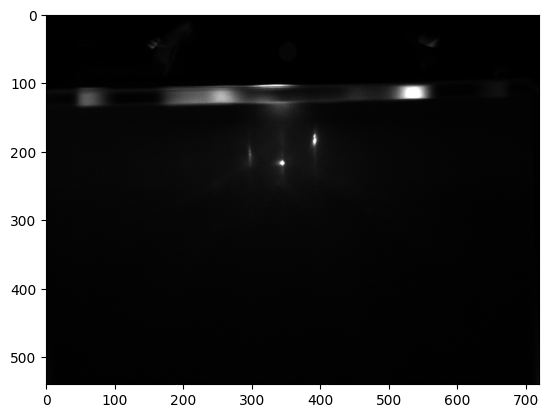

In [38]:
# Start the grabbing of c_countOfImagesToGrab images.
# The camera device is parameterized with a default configuration which
# sets up free-running continuous acquisition.
camera.StartGrabbingMax(countOfImagesToGrab)

# Camera.StopGrabbing() is called automatically by the RetrieveResult() method
# when c_countOfImagesToGrab images have been retrieved.
while camera.IsGrabbing():
    # Wait for an image and then retrieve it. A timeout of 5000 ms is used.
    grabResult = camera.RetrieveResult(5000, pylon.TimeoutHandling_ThrowException)

    # Image grabbed successfully?
    if grabResult.GrabSucceeded():
        # Access the image data.
        print("SizeX: ", grabResult.Width, "SizeY: ", grabResult.Height)
        img = grabResult.Array
        # print("Gray value of first pixel: ", img[0, 0])
    else:
        print("Error: ", grabResult.ErrorCode, grabResult.ErrorDescription)
    grabResult.Release()
plt.imshow(img, cmap="gray")

In [39]:
camera.GammaEnable.Value

True

In [43]:
camera.ExposureTimeAbs.Value = 30000
camera.GainRaw.Value = 240
camera.GainAuto.SetValue("Off")

camera.Gamma.Value = 2
camera.GammaEnable.Value = True

camera.BlackLevelRaw.Value = 250

for aoi in camera.AutoFunctionAOISelector.GetSymbolics():
    print(aoi)
    camera.AutoFunctionAOISelector.SetValue(aoi)
    camera.AutoFunctionAOIUsageIntensity.SetValue(True)
    print(camera.AutoFunctionAOIUsageIntensity.Value)
    camera.AutoFunctionAOIUsageWhiteBalance.SetValue(True)
    print(camera.AutoFunctionAOIUsageWhiteBalance.Value)

AOI1
True
True
AOI2
True
True


SizeX:  720 SizeY:  540
SizeX:  720 SizeY:  540
SizeX:  720 SizeY:  540
SizeX:  720 SizeY:  540
SizeX:  720 SizeY:  540


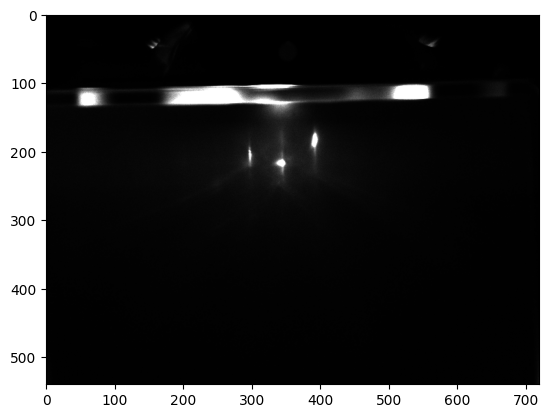

In [44]:
# Start the grabbing of c_countOfImagesToGrab images.
# The camera device is parameterized with a default configuration which
# sets up free-running continuous acquisition.
camera.StartGrabbingMax(countOfImagesToGrab)

# Camera.StopGrabbing() is called automatically by the RetrieveResult() method
# when c_countOfImagesToGrab images have been retrieved.
while camera.IsGrabbing():
    # Wait for an image and then retrieve it. A timeout of 5000 ms is used.
    grabResult = camera.RetrieveResult(5000, pylon.TimeoutHandling_ThrowException)

    # Image grabbed successfully?
    if grabResult.GrabSucceeded():
        # Access the image data.
        print("SizeX: ", grabResult.Width, "SizeY: ", grabResult.Height)
        img = grabResult.Array
        # print("Gray value of first pixel: ", img[0, 0])
    else:
        print("Error: ", grabResult.ErrorCode, grabResult.ErrorDescription)
    grabResult.Release()
plt.imshow(img, cmap="gray")

In [40]:
camera.Close()